**Install Required Libraries**

In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 4.5 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 6.1 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 7.2 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 7.6 MB/s  0:00:01
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.8/37.3 MB 12.2 MB/s eta 0:00:03
   ---- ----------------------------------- 4.2/37.3 MB 9.4 MB/s eta 0:00:04
   ------ --------------------------------- 6.3/37.3 MB 9.4 MB/s eta 0:00:04
   ------- -------------------------------- 7.3/37.3 MB 8.4 MB/s eta 0:00:04
   -------- ------------------------------- 8.4/37.3 MB 7.8 MB/s eta 0:00:04
   ---------- ---------------

**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [5]:
df = pd.read_csv(r"C:\Users\bharg\OneDrive\Desktop\internship\bank.csv", sep=';')

**Understand Data**

In [6]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')


In [7]:
print(df['y'].value_counts())

y
no     4000
yes     521
Name: count, dtype: int64


**Data Preprocessing**

In [8]:
df = pd.get_dummies(df, drop_first=True)

**Split Features & Target**

In [9]:
X = df.drop('y_yes', axis=1)  # Features
y = df['y_yes']              # Target

**Train-Test Split**

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train Decision Tree Model**

In [11]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

**Make Predictions**

In [12]:
y_pred = model.predict(X_test)

**Evaluate Model**

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.881767955801105
[[749  58]
 [ 49  49]]
              precision    recall  f1-score   support

       False       0.94      0.93      0.93       807
        True       0.46      0.50      0.48        98

    accuracy                           0.88       905
   macro avg       0.70      0.71      0.71       905
weighted avg       0.89      0.88      0.88       905



**Visualize Decision Tree**

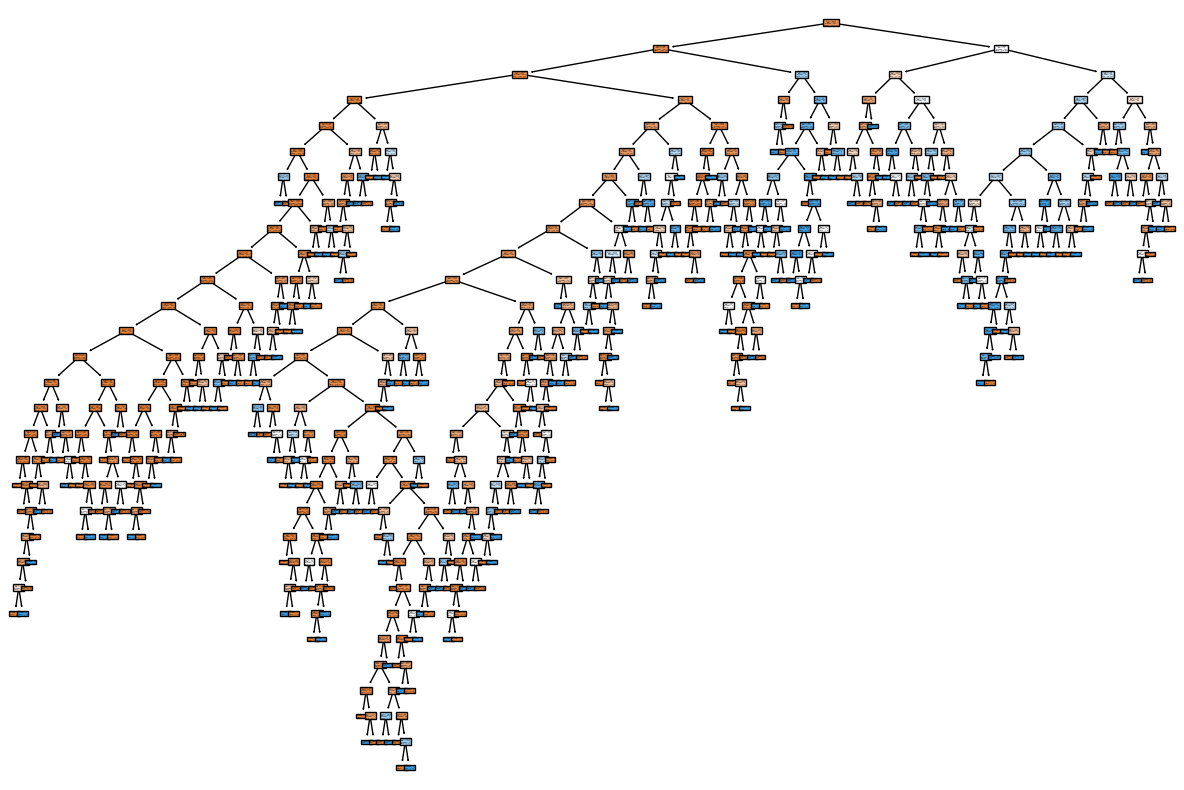

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(model, filled=True)
plt.show()

**Control Overfitting**

In [15]:
model = DecisionTreeClassifier(max_depth=5, min_samples_split=10)

**Feature Importance**

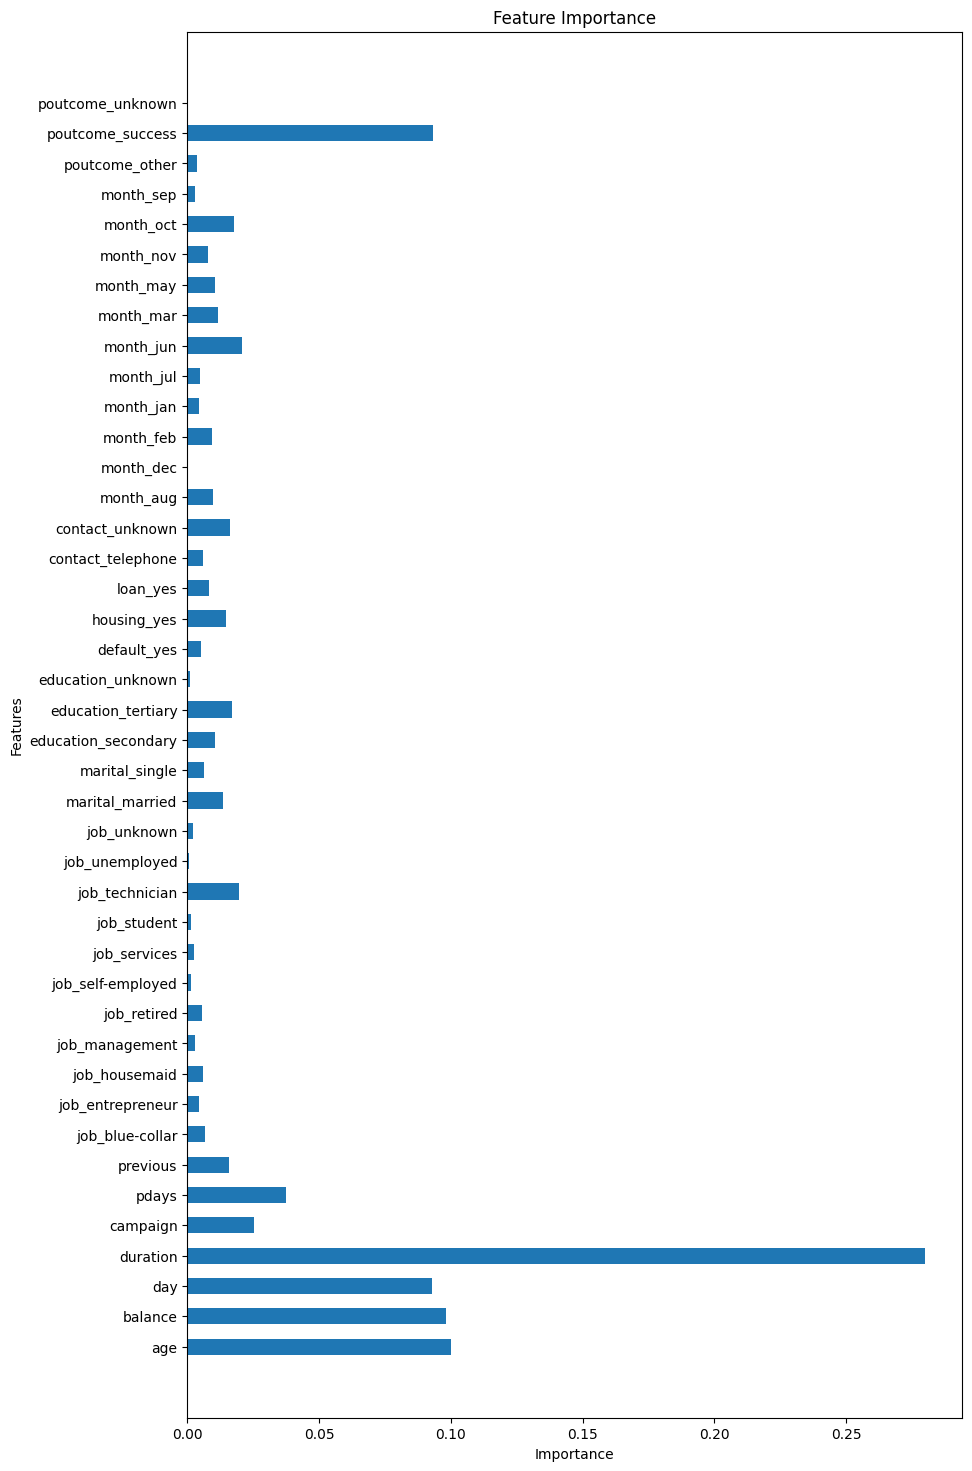

In [20]:
import numpy as np

y_pos = np.arange(len(feature_names)) * 1.5  # spacing multiplier

plt.figure(figsize=(10, 18))
plt.barh(y_pos, importances)

plt.yticks(y_pos, feature_names)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.show()